# Phase 1 — Analyse exploratoire (EDA)

**Projet :** Optimisation d'un modèle hybride CNN-LSTM pour la détection de la fibrillation auriculaire à partir des séries d'intervalles RR.

**Objectif de ce notebook.** Décrire la matière première du projet — les séries RR — avant toute modélisation.
Cinq angles d'analyse :

1. **Stats descriptives par dataset** — taille, nombre de patients, taux d'AFib.
2. **Distribution des durées RR par classe** — AFib vs non-AFib.
3. **Déséquilibre par patient** — un patient = un sujet, et la prévalence d'AFib varie énormément.
4. **Poincaré plots** (RR_n vs RR_n+1) — signature visuelle classique du rythme : nuage compact pour NSR, dispersion pour AFib.
5. **Séries RR brutes** — NSR pur, AFib pur, et transitions paroxystiques.

Toutes les figures sont sauvegardées sous `reports/figures/` pour réutilisation directe dans le mémoire.

## 0. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import list_records, load_record_metadata
from src.data.rr_extract import clean_rr_series, extract_rr_series

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

DATASET_LABELS = {
    "afdb": "MIT-BIH AFib DB",
    "nsrdb": "MIT-BIH NSR DB",
    "ltafdb": "Long-Term AFib DB",
}
CLASS_COLORS = {"NSR": "#1f77b4", "AFib": "#d62728"}
RNG = np.random.default_rng(42)
print("Project root:", PROJECT_ROOT)
print("Figures ->", FIG_DIR)

Project root: /home/abdou/Master
Figures -> /home/abdou/Master/reports/figures


In [2]:
def load_processed(name: str) -> dict:
    """Load a processed .npz file as a dict of arrays."""
    arr = np.load(PROCESSED_DIR / f"{name}.npz", allow_pickle=True)
    return {"X": arr["X"], "y": arr["y"], "patient_id": arr["patient_id"]}

datasets = {name: load_processed(name) for name in DATASET_LABELS}
for name, d in datasets.items():
    print(f"{name:7s}  X={d['X'].shape}  y_afib={d['y'].mean():.3f}  n_patients={len(np.unique(d['patient_id']))}")

afdb     X=(81263, 30)  y_afib=0.435  n_patients=25
nsrdb    X=(115221, 30)  y_afib=0.000  n_patients=18
ltafdb   X=(599579, 30)  y_afib=0.581  n_patients=84


## 1. Stats descriptives par dataset

On compare nos trois sources :

- **AFDB** — entraînement / validation principale, taux d'AFib élevé par construction.
- **NSRDB** — exemples négatifs purs (sujets sains), zéro AFib attendu.
- **LTAFDB** — évaluation externe (généralisation), enregistrements de 24-25 h.

Ces chiffres pilotent les choix de pondération de loss et de stratégie d'échantillonnage à venir.

In [3]:
rows = []
for name, d in datasets.items():
    y = d["y"]
    pids = d["patient_id"]
    rows.append({
        "dataset": name,
        "label": DATASET_LABELS[name],
        "n_windows": int(len(y)),
        "n_patients": int(len(np.unique(pids))),
        "afib_rate": float(y.mean()),
        "n_afib_windows": int(y.sum()),
        "n_nsr_windows": int((1 - y).sum()),
        "windows_per_patient_median": float(np.median(np.bincount(np.unique(pids, return_inverse=True)[1]))),
    })
summary = pd.DataFrame(rows).set_index("dataset")
summary

,label,n_windows,n_patients,afib_rate,n_afib_windows,n_nsr_windows,windows_per_patient_median
dataset,,,,,,,
afdb,MIT-BIH AFib DB,81263,25,0.435180,35364,45899,3190.0
nsrdb,MIT-BIH NSR DB,115221,18,0.000000,0,115221,6599.5
ltafdb,Long-Term AFib DB,599579,84,0.581234,348496,251083,7205.5


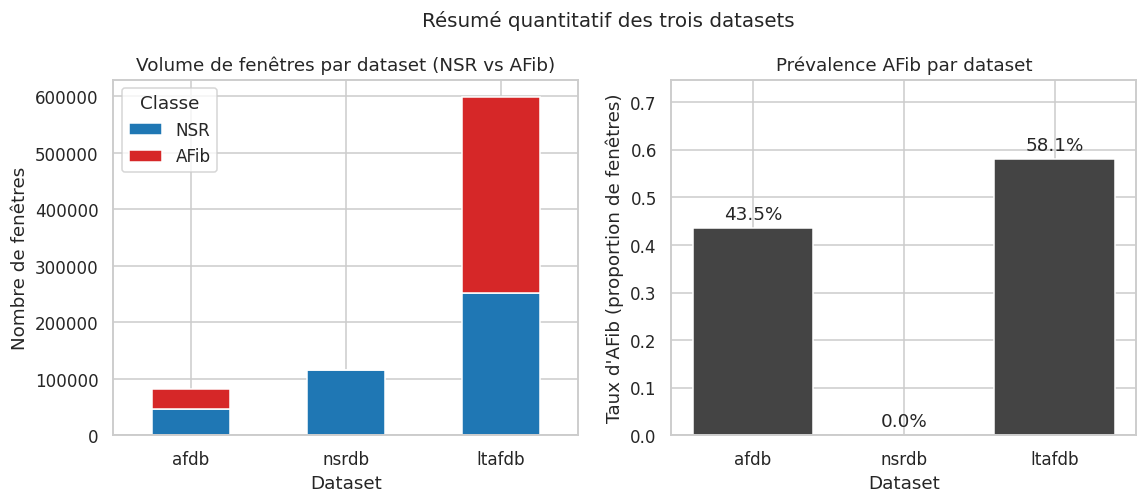

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
bars = summary[["n_nsr_windows", "n_afib_windows"]].rename(
    columns={"n_nsr_windows": "NSR", "n_afib_windows": "AFib"}
)
bars.plot(kind="bar", stacked=True, ax=ax, color=[CLASS_COLORS["NSR"], CLASS_COLORS["AFib"]])
ax.set_ylabel("Nombre de fenêtres")
ax.set_xlabel("Dataset")
ax.set_title("Volume de fenêtres par dataset (NSR vs AFib)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Classe")

ax = axes[1]
rates = summary["afib_rate"]
ax.bar(rates.index, rates.values, color=["#444"] * len(rates))
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", va="bottom")
ax.set_ylim(0, max(rates.values) * 1.2 + 0.05)
ax.set_ylabel("Taux d'AFib (proportion de fenêtres)")
ax.set_xlabel("Dataset")
ax.set_title("Prévalence AFib par dataset")

fig.suptitle("Résumé quantitatif des trois datasets", y=1.03, fontsize=13)
fig.savefig(FIG_DIR / "01_dataset_summary.png")
plt.show()

**Lecture.** NSRDB est totalement sain (0 % AFib) et joue le rôle de pool de négatifs purs. AFDB est presque équilibré (~43 %), ce qui le rend confortable pour l'entraînement. LTAFDB est dominé par l'AFib (~58 %) car ce sont des enregistrements de très longue durée centrés sur des patients AFib chroniques — c'est notre stress test de généralisation.

## 2. Distribution des durées RR par classe

Première intuition clé : la moyenne et la variance des intervalles RR diffèrent entre rythme sinusal et AFib. On le visualise au niveau **battement** (et non fenêtre) pour rester proche du signal physiologique.

On agrège AFDB + LTAFDB (sources avec les deux classes) ; le label de chaque RR est inféré du label de la fenêtre qui le contient.

In [5]:
def flatten_rr_with_labels(ds: dict, max_samples: int | None = 400_000) -> tuple[np.ndarray, np.ndarray]:
    """Concat all RR values and replicate the window label across each window."""
    X = ds["X"].astype(np.float32)
    y = ds["y"].astype(np.int8)
    rr_flat = X.reshape(-1)
    lab_flat = np.repeat(y, X.shape[1])
    if max_samples is not None and len(rr_flat) > max_samples:
        idx = RNG.choice(len(rr_flat), size=max_samples, replace=False)
        rr_flat = rr_flat[idx]
        lab_flat = lab_flat[idx]
    return rr_flat, lab_flat

rr_afdb, lab_afdb = flatten_rr_with_labels(datasets["afdb"])
rr_ltaf, lab_ltaf = flatten_rr_with_labels(datasets["ltafdb"])
rr_all = np.concatenate([rr_afdb, rr_ltaf])
lab_all = np.concatenate([lab_afdb, lab_ltaf])
lab_named = np.where(lab_all == 1, "AFib", "NSR")
df_rr = pd.DataFrame({"rr_seconds": rr_all, "class": lab_named})
df_rr.groupby("class")["rr_seconds"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
AFib,406476.0,0.672,0.222,0.3,0.508,0.64,0.789,2.0
NSR,393524.0,0.825,0.188,0.3,0.695,0.82,0.944,2.0


/tmp/ipykernel_66755/3476239522.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_rr, x="class", y="rr_seconds", order=["NSR", "AFib"],


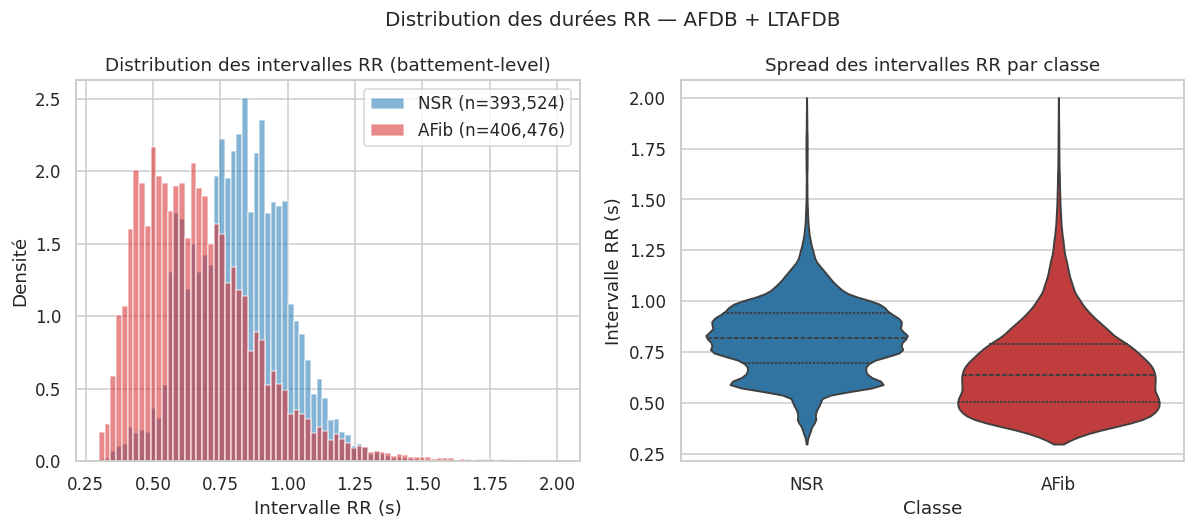

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for cls in ["NSR", "AFib"]:
    sub = df_rr.loc[df_rr["class"] == cls, "rr_seconds"]
    ax.hist(sub, bins=80, range=(0.3, 2.0), alpha=0.55, density=True,
            color=CLASS_COLORS[cls], label=f"{cls} (n={len(sub):,})")
ax.set_xlabel("Intervalle RR (s)")
ax.set_ylabel("Densité")
ax.set_title("Distribution des intervalles RR (battement-level)")
ax.legend()

ax = axes[1]
sns.violinplot(data=df_rr, x="class", y="rr_seconds", order=["NSR", "AFib"],
               palette=CLASS_COLORS, cut=0, inner="quartile", ax=ax)
ax.set_xlabel("Classe")
ax.set_ylabel("Intervalle RR (s)")
ax.set_title("Spread des intervalles RR par classe")

fig.suptitle("Distribution des durées RR — AFDB + LTAFDB", y=1.02, fontsize=13)
fig.savefig(FIG_DIR / "02_rr_distribution.png")
plt.show()

**Lecture.** Les deux distributions se chevauchent fortement en localisation (médiane proche), mais l'AFib présente une **dispersion sensiblement plus large** — lourdes queues des deux côtés du mode. C'est exactement le phénomène d'irrégularité que le modèle devra apprendre à détecter : ce n'est pas la valeur moyenne d'un RR qui trahit l'AFib, c'est sa variabilité d'un battement au suivant.

## 3. Déséquilibre de classes par patient

Un patient = une unité statistique. Si la prevalence d'AFib varie radicalement d'un patient à l'autre, un split mal conçu peut entraîner / valider sur des distributions très différentes. On regarde la **proportion d'AFib par patient** pour AFDB et LTAFDB (NSRDB est trivialement 0 partout).

In [7]:
def per_patient_afib_rate(ds: dict) -> pd.DataFrame:
    df = pd.DataFrame({"patient_id": ds["patient_id"], "y": ds["y"].astype(int)})
    g = df.groupby("patient_id").agg(n_windows=("y", "size"), afib_rate=("y", "mean"))
    return g.sort_values("afib_rate", ascending=False)

rates_afdb = per_patient_afib_rate(datasets["afdb"]).assign(dataset="afdb")
rates_ltaf = per_patient_afib_rate(datasets["ltafdb"]).assign(dataset="ltafdb")
rates_nsr = per_patient_afib_rate(datasets["nsrdb"]).assign(dataset="nsrdb")
rates_all = pd.concat([rates_afdb, rates_ltaf, rates_nsr])
print("Per-patient AFib rate summary:")
rates_all.groupby("dataset")["afib_rate"].describe().round(3)

Per-patient AFib rate summary:


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
afdb,25.0,0.407,0.366,0.003,0.058,0.241,0.743,1.0
ltafdb,84.0,0.545,0.424,0.000,0.099,0.482,1.000,1.0
nsrdb,18.0,0.000,0.000,0.000,0.000,0.000,0.000,0.0


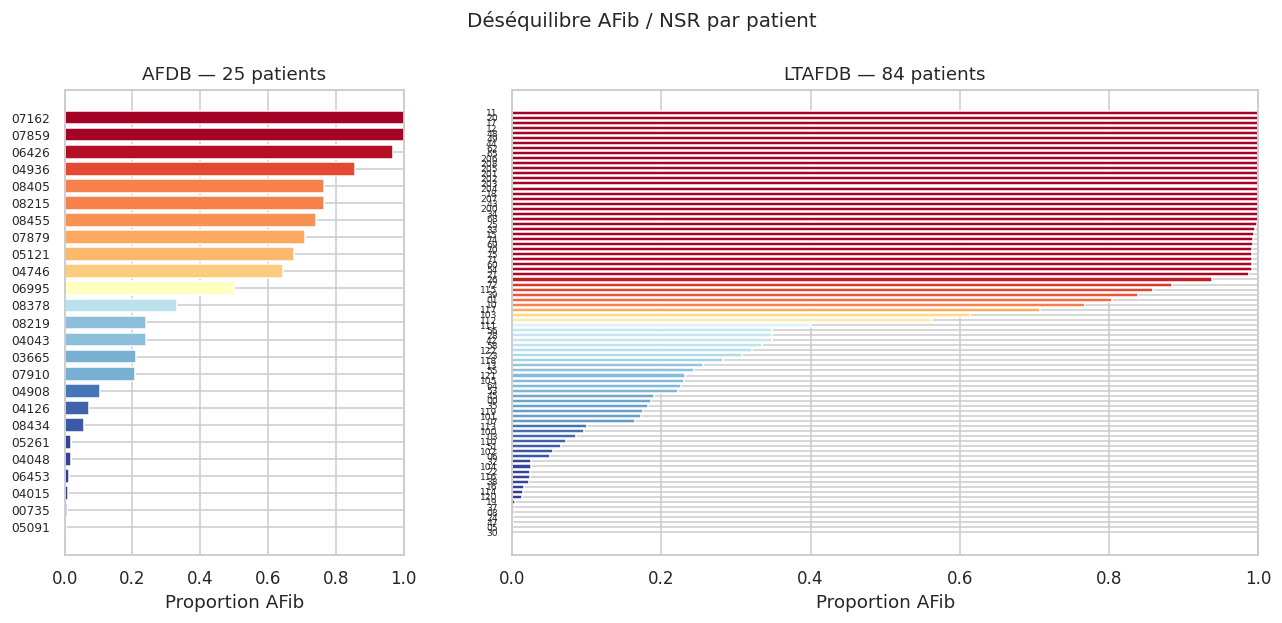

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw={"width_ratios": [1, 2.2]})

ax = axes[0]
order_afdb = rates_afdb.index.tolist()
ax.barh(range(len(order_afdb)), rates_afdb["afib_rate"].values,
        color=plt.cm.RdYlBu_r(rates_afdb["afib_rate"].values))
ax.set_yticks(range(len(order_afdb)))
ax.set_yticklabels(order_afdb, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Proportion AFib")
ax.set_xlim(0, 1)
ax.set_title(f"AFDB — {len(order_afdb)} patients")

ax = axes[1]
order_ltaf = rates_ltaf.index.tolist()
ax.barh(range(len(order_ltaf)), rates_ltaf["afib_rate"].values,
        color=plt.cm.RdYlBu_r(rates_ltaf["afib_rate"].values))
ax.set_yticks(range(len(order_ltaf)))
ax.set_yticklabels(order_ltaf, fontsize=6)
ax.invert_yaxis()
ax.set_xlabel("Proportion AFib")
ax.set_xlim(0, 1)
ax.set_title(f"LTAFDB — {len(order_ltaf)} patients")

fig.suptitle("Déséquilibre AFib / NSR par patient", y=1.01, fontsize=13)
fig.savefig(FIG_DIR / "03_class_imbalance_per_patient.png")
plt.show()

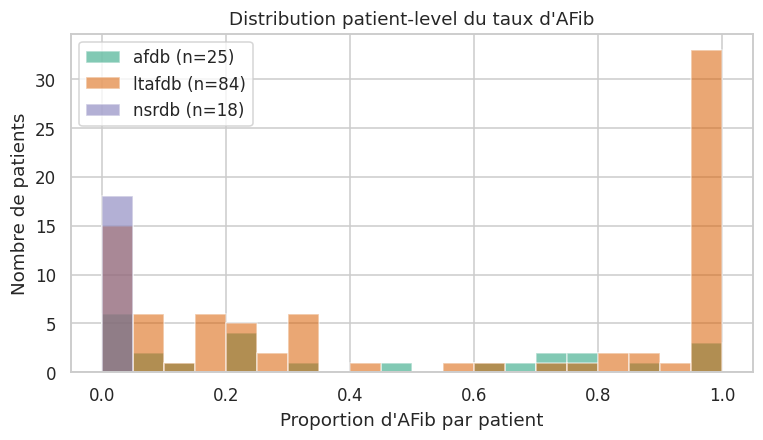

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for ds_name, color in zip(["afdb", "ltafdb", "nsrdb"], ["#1b9e77", "#d95f02", "#7570b3"]):
    sub = rates_all.loc[rates_all["dataset"] == ds_name, "afib_rate"]
    ax.hist(sub, bins=20, range=(0, 1), alpha=0.55, label=f"{ds_name} (n={len(sub)})", color=color)
ax.set_xlabel("Proportion d'AFib par patient")
ax.set_ylabel("Nombre de patients")
ax.set_title("Distribution patient-level du taux d'AFib")
ax.legend()
fig.savefig(FIG_DIR / "03b_patient_afib_rate_hist.png")
plt.show()

**Lecture.** La dispersion par patient est considérable : sur AFDB on trouve des sujets quasi-NSR et des sujets quasi-pure AFib. **Conséquence directe** : un split aléatoire au niveau fenêtre mélange beats du même patient entre train et test (data leakage). Le pipeline impose un split **GroupKFold sur `patient_id`** — déjà vérifié par `tests/test_patient_split.py`.

## 4. Poincaré plots (RR_n vs RR_{n+1})

Le Poincaré plot est *la* signature visuelle de la variabilité RR :

- **NSR** — nuage compact, allongé sur la diagonale (succession de RR voisins).
- **AFib** — éclaté en "étoile" / "comet" autour de la diagonale (RR successifs décorrélés).

On reconstruit les RR battement-par-battement depuis les annotations brutes pour rester fidèle à la temporalité (les fenêtres processed sont chevauchantes — stride=15 — et casseraient les liens RR_n / RR_{n+1}).

In [10]:
def load_raw_rr(dataset_id: str, record_name: str):
    """Re-extract a single record's RR series from raw PhysioNet files."""
    dataset_dir = RAW_DIR / dataset_id
    meta = load_record_metadata(dataset_dir, record_name)
    series = extract_rr_series(meta)
    return clean_rr_series(series, min_rr=0.3, max_rr=2.0)

afdb_records = list_records(RAW_DIR / "afdb")
nsrdb_records = list_records(RAW_DIR / "nsrdb")
print("AFDB records:", len(afdb_records), "NSRDB records:", len(nsrdb_records))

AFDB records: 25 NSRDB records: 18


In [11]:
def pick_records_with_afib_ratio(rates_df: pd.DataFrame, low: float, high: float, k: int = 1):
    mask = (rates_df["afib_rate"] >= low) & (rates_df["afib_rate"] <= high)
    return rates_df[mask].index.tolist()[:k]

afib_heavy = pick_records_with_afib_ratio(rates_afdb, 0.8, 1.0, k=1)
nsr_dominant = pick_records_with_afib_ratio(rates_afdb, 0.0, 0.1, k=1)
mixed = pick_records_with_afib_ratio(rates_afdb, 0.3, 0.7, k=1)
print("Pure-AFib AFDB record:", afib_heavy)
print("Pure-NSR AFDB record :", nsr_dominant)
print("Mixed AFDB record    :", mixed)
nsr_pure_record = nsrdb_records[0]
print("NSRDB record         :", nsr_pure_record)

Pure-AFib AFDB record: ['07162']
Pure-NSR AFDB record : ['04126']
Mixed AFDB record    : ['05121']
NSRDB record         : 16265


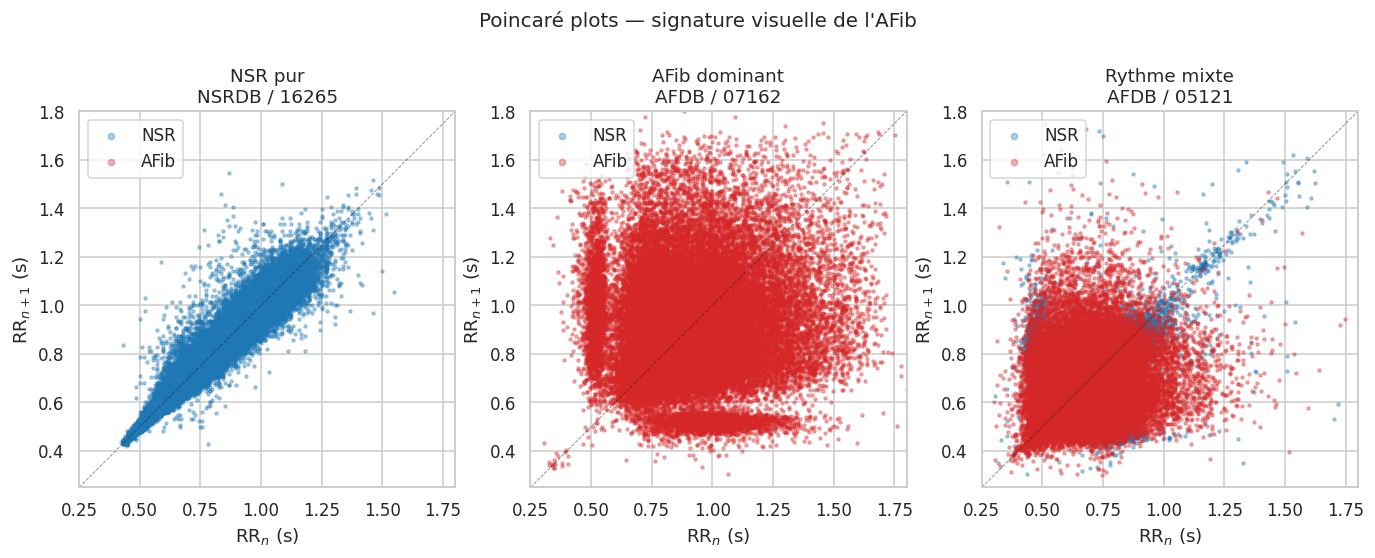

In [12]:
def poincare_xy(rr: np.ndarray):
    return rr[:-1], rr[1:]

series_nsr = load_raw_rr("nsrdb", nsr_pure_record)
series_afib = load_raw_rr("afdb", afib_heavy[0]) if afib_heavy else None
series_mix = load_raw_rr("afdb", mixed[0]) if mixed else None

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    (axes[0], series_nsr, "NSR pur", f"NSRDB / {nsr_pure_record}", "is_afib"),
    (axes[1], series_afib, "AFib dominant", f"AFDB / {afib_heavy[0]}" if afib_heavy else "", "is_afib"),
    (axes[2], series_mix, "Rythme mixte", f"AFDB / {mixed[0]}" if mixed else "", "is_afib"),
]

for ax, series, title, subtitle, _ in panels:
    if series is None or len(series.rr_seconds) < 2:
        ax.set_visible(False)
        continue
    x, y = poincare_xy(series.rr_seconds)
    lab = series.is_afib[1:]
    nsr_mask = lab == 0
    af_mask = lab == 1
    ax.scatter(x[nsr_mask], y[nsr_mask], s=4, alpha=0.35, color=CLASS_COLORS["NSR"], label="NSR")
    ax.scatter(x[af_mask], y[af_mask], s=4, alpha=0.35, color=CLASS_COLORS["AFib"], label="AFib")
    lim = (0.25, 1.8)
    ax.plot(lim, lim, "k--", lw=0.6, alpha=0.5)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")
    ax.set_xlabel("RR$_n$ (s)")
    ax.set_ylabel("RR$_{n+1}$ (s)")
    ax.set_title(f"{title}\n{subtitle}")
    ax.legend(loc="upper left", markerscale=2)

fig.suptitle("Poincaré plots — signature visuelle de l'AFib", y=1.02, fontsize=13)
fig.savefig(FIG_DIR / "04_poincare_afib_vs_nsr.png")
plt.show()

**Lecture.** Le contraste visuel est immédiat :

- En **NSR**, les points s'agglutinent autour d'un petit segment de la diagonale — chaque RR ressemble au précédent.
- En **AFib**, le nuage explose en étoile dans tout le quadrant — décorrélation totale entre RR successifs.
- Sur le record mixte, on lit les deux régimes superposés, ce qui confirme la pertinence d'un modèle qui décide **par fenêtre** plutôt que par patient.

## 5. Séries RR brutes

Pour terminer, on regarde le signal temporel lui-même : trois extraits de 5 minutes environ illustrant les trois régimes qui définissent le problème.

In [13]:
def slice_seconds(series, max_seconds: float = 300.0, start_beat: int = 0):
    """Take a sub-slice of an RRSeries up to ``max_seconds`` of cumulative time."""
    rr = series.rr_seconds[start_beat:]
    lab = series.is_afib[start_beat:]
    t = np.cumsum(rr)
    keep = t <= max_seconds
    return t[keep], rr[keep], lab[keep]

def find_transition_record():
    """Pick a mixed AFDB record whose AFib state actually changes within 5 min."""
    for rec in rates_afdb.index:
        if not (0.2 <= rates_afdb.loc[rec, "afib_rate"] <= 0.8):
            continue
        s = load_raw_rr("afdb", rec)
        t = np.cumsum(s.rr_seconds)
        idx = t <= 600.0
        lab = s.is_afib[idx]
        if lab.min() == 0 and lab.max() == 1:
            return rec, s
    return mixed[0] if mixed else afdb_records[0], load_raw_rr("afdb", mixed[0] if mixed else afdb_records[0])

transition_rec, series_transition = find_transition_record()
print("Transition record:", transition_rec)

Transition record: 05121


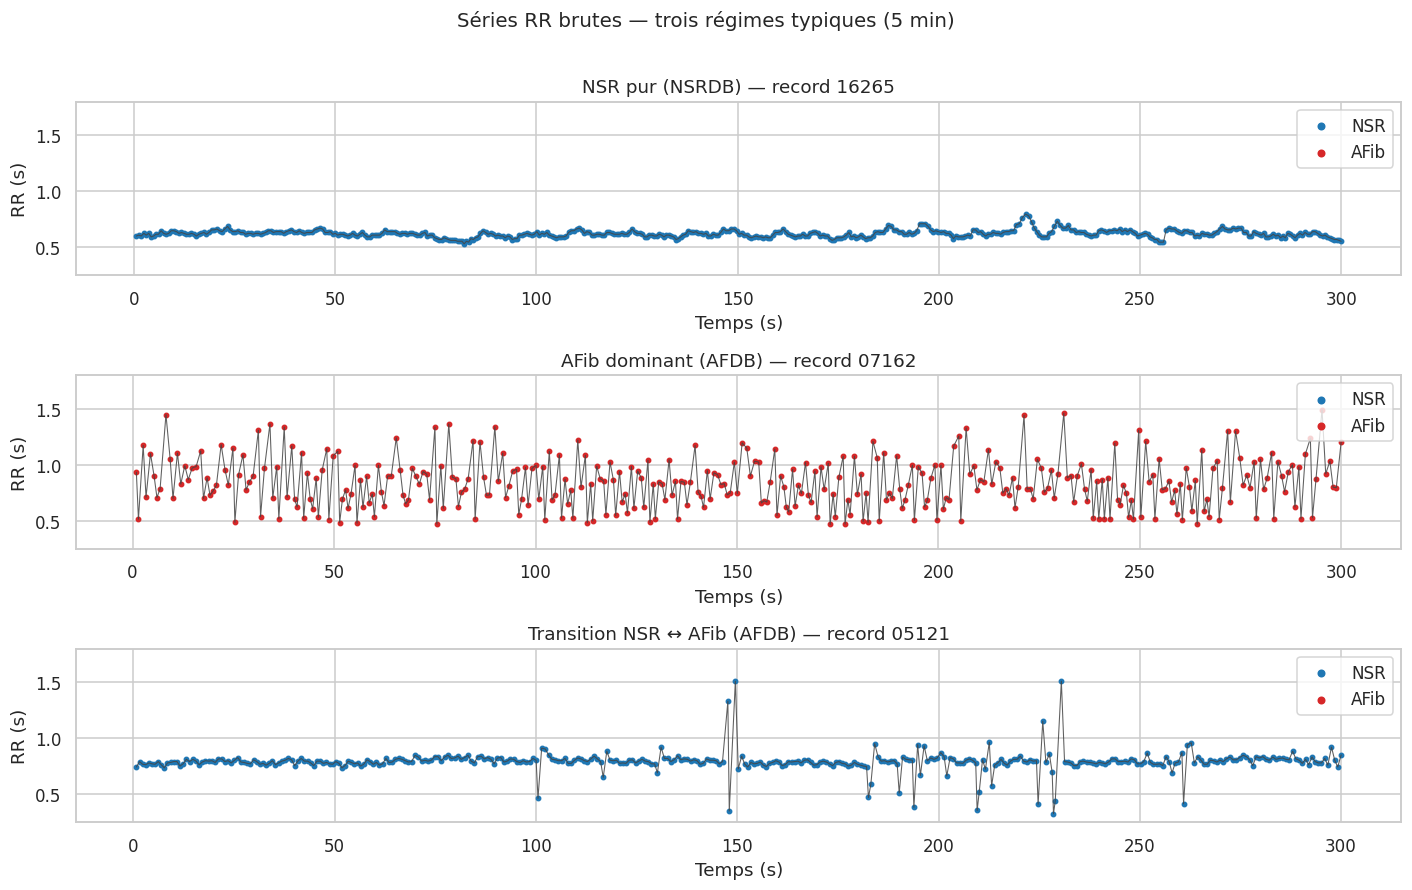

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=False)

examples = [
    (axes[0], series_nsr, "NSR pur (NSRDB)", nsr_pure_record),
    (axes[1], series_afib, "AFib dominant (AFDB)", afib_heavy[0] if afib_heavy else ""),
    (axes[2], series_transition, "Transition NSR ↔ AFib (AFDB)", transition_rec),
]

for ax, series, title, rec in examples:
    if series is None:
        ax.set_visible(False)
        continue
    t, rr, lab = slice_seconds(series, max_seconds=300.0)
    ax.plot(t, rr, color="#444", lw=0.7, alpha=0.85)
    nsr_mask = lab == 0
    af_mask = lab == 1
    ax.scatter(t[nsr_mask], rr[nsr_mask], s=8, color=CLASS_COLORS["NSR"], label="NSR")
    ax.scatter(t[af_mask], rr[af_mask], s=8, color=CLASS_COLORS["AFib"], label="AFib")
    ax.set_ylim(0.25, 1.8)
    ax.set_xlabel("Temps (s)")
    ax.set_ylabel("RR (s)")
    ax.set_title(f"{title} — record {rec}")
    ax.legend(loc="upper right", markerscale=1.5)

fig.suptitle("Séries RR brutes — trois régimes typiques (5 min)", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_raw_rr_examples.png")
plt.show()

**Lecture.** Trois traces, trois régimes :

- **NSR pur** — oscillation régulière et lente (respiration), variabilité *structurée*.
- **AFib pur** — oscillation rapide et erratique d'un battement au suivant, sans tendance lisse.
- **Transition** — le rythme bascule brutalement : c'est sur ce type de fenêtres que la qualité de la convolution temporelle (capture de motifs locaux) sera testée par le CNN-LSTM.

## Synthèse de la Phase 1

| Constat | Conséquence pour le modélisation |
|---|---|
| Trois datasets de prevalences AFib très différentes (0 % / 43 % / 58 %) | Politique de pondération de loss à définir, et évaluation externe sur LTAFDB |
| Forte variance de prevalence par patient | Split obligatoirement patient-level (GroupKFold) — validé par les tests |
| Recouvrement large des distributions RR moyennes | Pas d'apprentissage à partir d'un simple seuil sur RR moyen |
| Variabilité RR explose en AFib (Poincaré) | Features HRV (RMSSD, SD1/SD2) seront de bonnes baselines |
| Transitions paroxystiques courtes existent | Fenêtre de 30 battements (≈ 25 s) reste un compromis raisonnable mais à challenger |

Toutes les figures sont sous `reports/figures/` :

- `01_dataset_summary.png`
- `02_rr_distribution.png`
- `03_class_imbalance_per_patient.png`
- `03b_patient_afib_rate_hist.png`
- `04_poincare_afib_vs_nsr.png`
- `05_raw_rr_examples.png`

**Prochaine étape (Phase 2)** — baselines : seuils sur HRV (RMSSD), régression logistique sur features HRV, puis un petit CNN nu pour calibrer la barre avant le CNN-LSTM.